# Aprendizaje Profundo
## Tarea 3 - Redes Basadas en Atención
### Eduardo García


### Clasificación de rostros por grupo etario mediante ViT
Entrena y evalúa modelos de clasificación de rostros por grupo etario basados en la arquitectura ViT, usando el conjunto de datos FairFace. Agrega un bloque ResNet después de la capa convolucional que procesa los parches en ViT, entrena un modelo con la arquitecturañ modificada y compara su desempeño con ViT. Disctuteñ los resultados que obtuviste con las diferentes configuraciones. Para reducir el tiempo de entrenamiento puedes usar resoluciones de imágenes más pequeñas, como 64x64 o incluso 32x32.

### Bibliotecas

In [39]:
# marcas de tiempo
import datetime
# explorar el sistema de archivos
import glob
# sistema de archivos
import os
# funciones aleatorias
import random
# marcas de tiempo
import time
# tomar n elementos de una secuencia
from itertools import islice as take
# gráficas
import matplotlib.patches as patches
import matplotlib.pyplot as plt
# arreglos multidimensionales
import numpy as np
# csv
import pandas as pd
# redes neuronales
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as T
# cargador de datos
from torch.utils.data import DataLoader, Dataset
# inspección de arquitectura
from torchinfo import summary
# barra de progreso
from tqdm.auto import trange
# imágenes
from PIL import Image

from einops import rearrange, repeat

In [40]:
DC = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'{DC = }')

DC = 'cpu'


### Funciones auxiliaries

In [41]:
def set_seed(seed=42):
  """Initializes pseudo-random number generators."""
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)


# reproducibilidad
set_seed()

## Dataset

In [42]:
df_train = pd.read_csv('./fairface_label_train.csv')
df_val = pd.read_csv('./fairface_label_val.csv')


In [43]:
df_train.race = pd.Categorical(df_train.race)
df_val.race = pd.Categorical(df_val.race)

df_train['race_ind'] = df_train.race.cat.codes
df_val['race_ind'] = df_val.race.cat.codes

In [44]:
df_train.head(10)

,file,age,gender,race,service_test,race_ind
0,train/1.jpg,50-59,Male,East Asian,True,1
1,train/2.jpg,30-39,Female,Indian,False,2
2,train/3.jpg,3-9,Female,Black,False,0
3,train/4.jpg,20-29,Female,Indian,True,2
4,train/5.jpg,20-29,Female,Indian,True,2
5,train/6.jpg,20-29,Male,White,True,6
6,train/7.jpg,40-49,Male,Middle Eastern,False,4
7,train/8.jpg,30-39,Female,Indian,True,2
8,train/9.jpg,10-19,Male,White,True,6
9,train/10.jpg,30-39,Male,Middle Eastern,False,4


In [45]:
df_val.head(10)

,file,age,gender,race,service_test,race_ind
0,val/1.jpg,3-9,Male,East Asian,False,1
1,val/2.jpg,50-59,Female,East Asian,True,1
2,val/3.jpg,30-39,Male,White,True,6
3,val/4.jpg,20-29,Female,Latino_Hispanic,True,3
4,val/5.jpg,20-29,Male,Southeast Asian,False,5
5,val/6.jpg,30-39,Male,Latino_Hispanic,False,3
6,val/7.jpg,20-29,Male,Black,True,0
7,val/8.jpg,3-9,Male,East Asian,False,1
8,val/9.jpg,20-29,Male,Southeast Asian,False,5
9,val/10.jpg,3-9,Male,Southeast Asian,False,5


In [46]:
# tamaño del lote
BATCH_SIZE = 32
# tamaño de la imagen
IMG_SIZE = 64

In [47]:
# transformación de entrenamiento
tr_ent = T.Compose([
  # Aplicamos un randon size crop para tener imágenes más pequeñas 
  # (y por ende más rápidas de procesar)
  T.RandomResizedCrop(64, scale=(.85, 1.0), antialias=True), #64x64 como en el notebook
  # Giramos aleatoriamente en el eje horizontal
  T.RandomHorizontalFlip(),
  # Hacemos una rotación aleatoria
  T.RandomRotation(degrees=90),
  # Por ultimo hacemos que la imagen sea un tensor
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

In [48]:
# transformación de validación
tr_val = T.Compose([
  T.Resize(64, antialias=True),
  # T.ToImage(),
  # T.ToDtype(th.float32, scale=True)
  T.ToTensor()
])

In [49]:
def muestra_imagenes(imgs, etiq):
  t_muestra = imgs.shape[0]
  n_filas = n_cols = int(np.sqrt(t_muestra))

  fig, ax = plt.subplots(nrows=n_filas, ncols=n_cols, figsize=(2 * n_filas,
                                                               2 * n_cols))
  for i in range(n_filas):
    for j in range(n_cols):
      idx = i * n_filas + j
      ax[i, j].imshow(imgs[idx])
      ax[i, j].axis('off')
      ax[i, j].set_title(etiq[idx])
  plt.tight_layout()
  plt.show()

In [50]:
# Definimos el DataLoader

class FaceLoader(Dataset):
  def __init__(self, df, root, transform=None):
    self.df = df
    self.root = root
    self.transform = transform

  def __getitem__(self, idx):
    # Abrimos la imagen
    img = Image.open(self.root + self.df.file.iloc[idx])
    # Obtenemos la categoría del dataframe
    cat = self.df.race_ind.iloc[idx]

    # En caso de tener una transformación
    if self.transform:
      img = self.transform(img)

    return img, torch.tensor(cat, dtype=torch.long)
  
  def __len__(self):
    return len(self.df)

In [51]:
rootDir = './fairface-img-margin025-trainval/'

In [58]:
ds_ent = FaceLoader(df=df_train, root=rootDir)
ds_val = FaceLoader(df=df_val, root=rootDir)

In [59]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent = }, {cat_ent = }')

img_ent = <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x7CDC32D2BC40>, cat_ent = tensor(1)


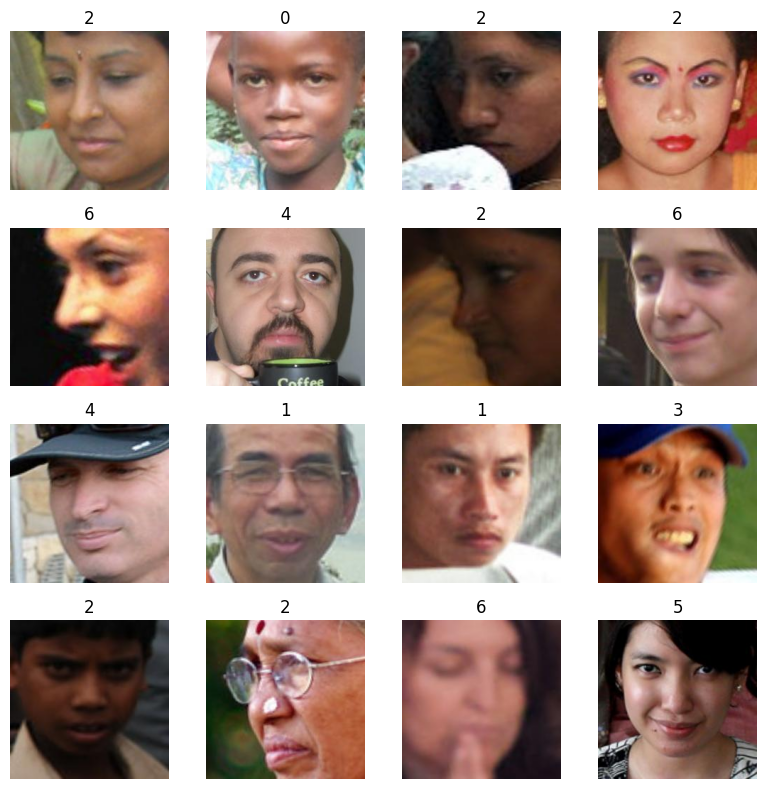

In [60]:
muestras = [next(it_ent) for i in range(16)]
imgs = [np.array(m[0]) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), np.array(cats))

In [61]:
ds_ent.transform  = tr_ent
ds_val.transform  = tr_val

In [62]:
# Definimos un iterador para poder ir cargando las imágenes
it_ent = iter(ds_ent)
img_ent, cat_ent = next(it_ent)

print(f'{img_ent.shape = }, {cat_ent = }')

img_ent.shape = torch.Size([3, 64, 64]), cat_ent = tensor(1)


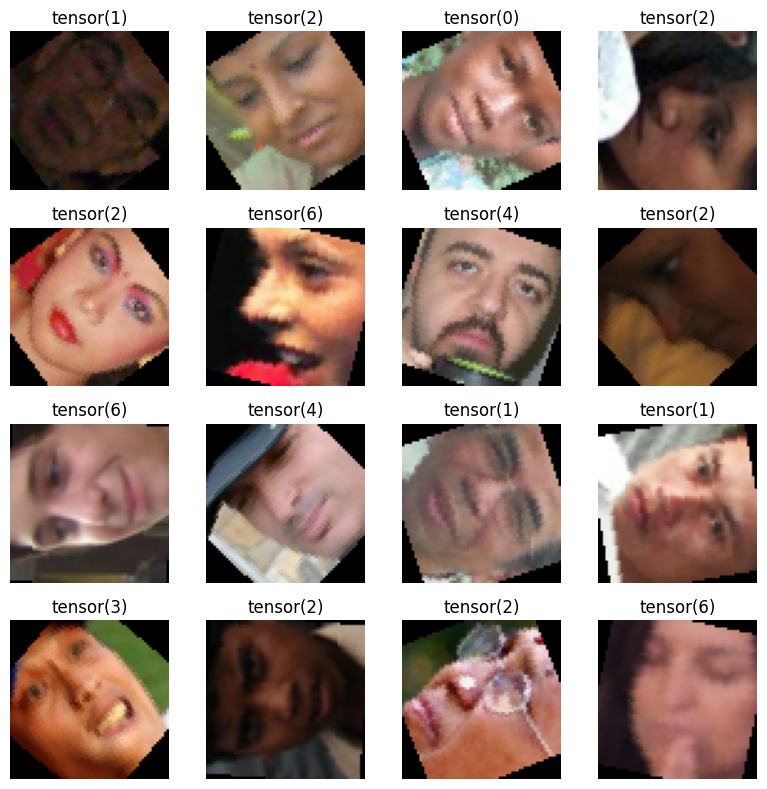

In [64]:
it = iter(ds_ent)
muestras = [next(it) for i in range(16)]
imgs = [np.array(m[0].permute(1, 2, 0)) for m in muestras]
cats = [m[1] for m in muestras]

muestra_imagenes(np.array(imgs), cats)

In [ ]:
from torch.utils.data import DataLoader

In [65]:
T_LOTE = 64

In [66]:
entdl = DataLoader(ds_ent,
                   batch_size=T_LOTE,
                   shuffle=True)

valdl = DataLoader(ds_val,
                   batch_size=T_LOTE,
                   shuffle=True)

In [82]:
train_batch = next(iter(entdl))

In [83]:
train_batch[0].shape

torch.Size([64, 3, 64, 64])

## Modelo

In [67]:
class ProductoPuntoEscalado(nn.Module):
  def __init__(self,
               masc = False):
    super(ProductoPuntoEscalado, self).__init__()
    self.masc = masc

  def forward(self, Q, K, V):
    # Obtenemos dimensiones
    m, n_cabezas, l, d_k = K.shape
    d_v = V.shape[-1]

    # Cambiamos la forma: [m, n_cabezas, l, d_k] -> [m * n_cabezas, l, d_k]
    Q = Q.reshape(m * n_cabezas, l, d_k)
    K = K.reshape(m * n_cabezas, l, d_k)
    V = V.reshape(m * n_cabezas, l, d_v)

    # Q y K tienen forma [m * n_cabezas, l, d_k],
    # por lo que se transponen las dos últimas dimensiones de K
    # QK: [m * n_cabezas, l, l]
    QK = torch.bmm(Q, K.transpose(1, 2))

    # se escalan los valores QK
    QK_esc = QK / torch.math.sqrt(d_k)

    if self.masc:
      # Creamos una matriz triangular superior binaria (excluyendo la diagonal)
      masc = torch.triu(torch.ones((l, l), dtype = torch.bool, device = Q.device),
                     diagonal = 1)
      # Ponemos los valores de QK_esc en los que la máscara sea 1 a -inf
      QK_esc = QK_esc.masked_fill_(masc, -torch.inf)

    # mapas de atención: [m * n_cabezas, l, l] -> [m * n_cabezas, l, l]
    alfas = nn.functional.softmax(QK_esc, dim=-1)

    # vectores de salida y
    # alfas: [m * n_cabezas, l, l], V: [m * n_cabezas, l, d_v]
    # Y: [m * n_cabezas, l, d_v]
    Y = torch.bmm(alfas, V)

    # Cambiamos la forma: [m * n_cabezas, l, d_v] -> [m, n_cabezas, l, d_v]
    Y = Y.reshape(m, n_cabezas, l, d_v)

    # Cambiamos la forma: [m * n_cabezas, l, l] -> [m, n_cabezas, l, l]
    alfas = alfas.reshape(m, n_cabezas, l, l)

    return Y, alfas


In [68]:
class AtencionMulticabeza(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               masc = False):
    super(AtencionMulticabeza, self).__init__()

    self.n_cabezas = n_cabezas
    self.d_modelo = d_modelo

    self.ppe = ProductoPuntoEscalado(masc = masc)
    self.proy_Q = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_K = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_V = nn.Linear(self.d_modelo, self.d_modelo, bias = False)
    self.proy_sal = nn.Linear(self.d_modelo, self.d_modelo)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma del tensor x
    # [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Proyectamos vectores en x a Q, K, V
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Q = self.proy_Q(x)
    K = self.proy_K(x)
    V = self.proy_V(x)

    # Cambiamos la forma: [m * l, d_modelo] -> [m, l, n_cabezas, d_k]
    # d_k = d_v = self.d_modelo // self.n_cabezas
    Q = Q.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)
    K = K.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)
    V = V.reshape(m, l, self.n_cabezas, self.d_modelo // self.n_cabezas)

    # Transponemos el eje de las cabezas a la segunda posición del tensor y
    # creamos copia (con .contiguous()) para que esté almacenado en memoria de
    # forma contigua (.transpose() hace que ya no sea así).
    # [m, l, n_cabezas, d_k] -> [m, n_cabezas, l, d_k]
    Q = Q.transpose(1, 2).contiguous()
    K = K.transpose(1, 2).contiguous()
    V = V.transpose(1, 2).contiguous()

    # Calculamos el producto punto escalado con Q, K y V
    # Q, K: [m, n_cabezas, l, d_k], V:[m, n_cabezas, l, d_v]
    # Y: [m, n_cabezas, l, d_v], alfas: [m, n_cabezas, l, l]
    Y, alfas = self.ppe(Q, K, V)

    # Transponermos el eje de cabezas a la penúltima posición:
    # [m, n_cabezas, l, d_k] -> [m, l, n_cabezas, d_k]
    Y = Y.transpose(1, 2).contiguous()

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m, l, n_cabezas, d_k] -> [m * l, d_modelo]
    # d_modelo = n_cabezas * d_k
    Y = Y.reshape(m * l, self.d_modelo)

    # Proyectamos la vectores concatenados para obtener la salida
    # [m * l, d_modelo] -> [m * l, d_modelo]
    Y = self.proy_sal(Y)

    # Concatemanos los vectores de todas las cabezas en un solo vector
    # [m * l, d_modelo] -> [m, l, d_modelo]
    Y = Y.reshape(m, l, self.d_modelo)

    return Y, alfas

In [69]:
amc = AtencionMulticabeza(32, 2)
amc(torch.ones([1, 256, 32]))[0].shape

torch.Size([1, 256, 32])

In [70]:
class RedDensaPosicion(nn.Module):
  def __init__(self,
               d_modelo,
               d_ff,
               p_dropout):

    super(RedDensaPosicion, self).__init__()
    self.d_modelo = d_modelo
    self.d_ff = d_ff

    self.densa1 = nn.Linear(self.d_modelo, self.d_ff)
    self.densa2 = nn.Linear(self.d_ff, self.d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)
    self.dropout2 = nn.Dropout(p_dropout)

  def forward(self, x):
    m, l, d_modelo = x.shape

    # Cambiamos la forma: [m, l, d_modelo] -> [m * l, d_modelo]
    x = x.reshape(m * l, d_modelo)

    # Pasamos el tensor redimensionado por la red densa
    # [m * l, d_modelo] -> [m * l, d_modelo]
    x = self.densa1(x)
    x = nn.functional.gelu(x)
    x = self.dropout1(x)

    x = self.densa2(x)
    x = self.dropout2(x)

    # Lo regresamos a su forma original
    # [m * l, d_modelo] -> [m, l, d_modelo]
    x = x.reshape(m, l, d_modelo)

    return x

In [71]:
class BloqueTransformer(nn.Module):
  def __init__(self,
               d_modelo,
               n_cabezas,
               d_rdp,
               p_dropout = 0.0,
               masc = False):
    super(BloqueTransformer, self).__init__()

    self.amc = AtencionMulticabeza(d_modelo = d_modelo,
                                   n_cabezas = n_cabezas,
                                   masc = masc)
    self.norm1 = nn.LayerNorm(d_modelo)
    self.norm2 = nn.LayerNorm(d_modelo)

    self.dropout1 = nn.Dropout(p_dropout)

    self.mlp = RedDensaPosicion(d_modelo, d_rdp, p_dropout)

  def forward(self, x):
    x_ln1 = self.norm1(x)
    salidas_amc, alfas = self.amc(x_ln1)
    salidas_amc = self.dropout1(salidas_amc)

    x = salidas_amc + x
    x_ln2 = self.norm2(x)
    mlp = self.mlp(x_ln2)
    out = mlp + x

    return out

In [72]:
test_layer = BloqueTransformer(64, 2, 256)
test_layer(torch.ones([1, 64, 64])).shape

torch.Size([1, 64, 64])

In [73]:
summary(test_layer, (1, 64, 64), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
BloqueTransformer                        [1, 64, 64]               --
├─LayerNorm: 1-1                         [1, 64, 64]               128
├─AtencionMulticabeza: 1-2               [1, 64, 64]               --
│    └─Linear: 2-1                       [64, 64]                  4,096
│    └─Linear: 2-2                       [64, 64]                  4,096
│    └─Linear: 2-3                       [64, 64]                  4,096
│    └─ProductoPuntoEscalado: 2-4        [1, 2, 64, 32]            --
│    └─Linear: 2-5                       [64, 64]                  4,160
├─Dropout: 1-3                           [1, 64, 64]               --
├─LayerNorm: 1-4                         [1, 64, 64]               128
├─RedDensaPosicion: 1-5                  [1, 64, 64]               --
│    └─Linear: 2-6                       [64, 256]                 16,640
│    └─Dropout: 2-7                      [64, 256]                 

In [74]:
class Residual(nn.Module):
  def __init__(self,
               cent,
               csal,
               downsample = False):
    super(Residual, self).__init__()

    stride = 1

    if downsample:
      stride = 2

    if cent != csal or downsample:
      self.conv1x1 = nn.Conv2d(cent, csal, 1, stride = stride, padding = 0)
    else:
      self.conv1x1 = None

    self.conv1 = nn.Conv2d(cent, csal, 3, stride = stride, padding = 1)
    self.bn1 = nn.BatchNorm2d(csal)
    self.conv2 = nn.Conv2d(csal, csal, 3, padding = 'same')
    self.bn2 = nn.BatchNorm2d(csal)

  def forward(self, x):
    y = self.conv1(x)
    y = self.bn1(y)
    y = nn.functional.relu(y)
    y = self.conv2(y)
    y = self.bn2(y)

    if self.conv1x1:
      x = self.conv1x1(x)

    return nn.functional.relu(x + y)

In [89]:
class ViT(nn.Module):
  def __init__(self, img_size, patch_size, out_dim, d_modelo,
                depth, n_cabezas, mlp_dim, dropout):
    super().__init__()
    self.d_modelo = d_modelo
    self.patch_size = patch_size
    # N = H*W/(P^2)
    self.n_patches = (img_size // patch_size) ** 2

    input_projection = 3*(patch_size ** 2) # C*PP

    self.projection = nn.Linear(input_projection, d_modelo) #
    self.ResNet = Residual(d_modelo, d_modelo)
    self.pos_embedding = nn.Parameter(
        torch.randn(1, self.n_patches + 1, d_modelo))


    self.cls_token = nn.Parameter(torch.randn(1, 1, d_modelo))

    bloques = [BloqueTransformer(d_modelo,
                                  n_cabezas,
                                  mlp_dim,
                                  dropout,
                                  masc = False) for _ in range(depth)]
    self.transformer = nn.Sequential(*bloques)
  
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(d_modelo),
        nn.Linear(d_modelo, out_dim),
    )

  def forward(self, x):
    B = x.shape[0]

    # Patches
    # N x (P^2 * C)
    # Donde:
    # N = HW/P^2

    #img_patches0 = x.reshape(B, self.n_patches, int((patch_size*patch_size)*C))

    img_patches = rearrange(x,
                    'b c (patch_x x) (patch_y y) -> b (x y) (patch_x patch_y c)',
                    patch_x=self.patch_size, patch_y=self.patch_size)

    print(f'{img_patches.shape = }')
    # Linear Projection
    x = self.projection(img_patches)
    print(f'{x.shape = }')
    # x = self.ResNet(x)
    cls_token = self.cls_token.repeat(B, 1, 1)
    x = torch.cat((cls_token, x), dim=1)
    x += self.pos_embedding

    x = self.transformer(x)
    x = x[:, 0, :]
    return self.mlp_head(x)

In [91]:
help(rearrange)

Help on function rearrange in module einops.einops:

rearrange(tensor: Union[~Tensor, List[~Tensor]], pattern: str, **axes_lengths) -> ~Tensor
    einops.rearrange is a reader-friendly smart element reordering for multidimensional tensors.
    This operation includes functionality of transpose (axes permutation), reshape (view), squeeze, unsqueeze,
    stack, concatenate and other operations.
    
    Examples for rearrange operation:
    
    ```python
    # suppose we have a set of 32 images in "h w c" format (height-width-channel)
    >>> images = [np.random.randn(30, 40, 3) for _ in range(32)]
    
    # stack along first (batch) axis, output is a single array
    >>> rearrange(images, 'b h w c -> b h w c').shape
    (32, 30, 40, 3)
    
    # concatenate images along height (vertical axis), 960 = 32 * 30
    >>> rearrange(images, 'b h w c -> (b h) w c').shape
    (960, 40, 3)
    
    # concatenated images along horizontal axis, 1280 = 32 * 40
    >>> rearrange(images, 'b h w c ->

In [92]:
train_batch[0].shape

torch.Size([64, 3, 64, 64])

In [90]:
patch_size = 16
out_dim = 10
d_modelo = 64
depth = 3

n_cabezas = 4
mlp_dim = 256
dropout = 0.5

vit = ViT(IMG_SIZE, patch_size, out_dim, d_modelo, depth, n_cabezas, mlp_dim, dropout)

test_out = vit(train_batch[0])
test_out.shape

img_patches.shape = torch.Size([64, 16, 768])
x.shape = torch.Size([64, 16, 64])


torch.Size([64, 10])